---
title: Memory comparison
---

# Memory usage: h5coro vs async-hdf5 vs async-hdf5 + zarrs

magg's Lambda workers are constrained to 10 GB of memory. Profiling
showed linear memory growth with h5coro when processing hundreds of
granules ([englacial/magg#4](https://github.com/englacial/magg/issues/4)).

This notebook uses [memray](https://bloomberg.github.io/memray/) to
profile peak memory for a magg-like workflow: read all 6 beams from
10 ATL06 granules over Antarctica with quality filtering and
weighted-mean aggregation. We compare three approaches:

1. **h5coro** (sequential)
2. **async-hdf5** with zarr-python's default codec pipeline
3. **async-hdf5** with zarrs-python's Rust codec pipeline

In [1]:
import warnings

warnings.filterwarnings("ignore", message="Numcodecs codecs are not in the Zarr")
warnings.filterwarnings(
    "ignore", category=UserWarning, message=".*does not have a Zarr V3 specification.*"
)
warnings.filterwarnings("ignore", category=FutureWarning, module="earthaccess")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tqdm")

In [2]:
import tempfile
from pathlib import Path
from urllib.parse import urlparse

import earthaccess
import numpy as np

auth = earthaccess.login()

results = earthaccess.search_data(
    short_name="ATL06",
    cloud_hosted=True,
    bounding_box=(-120, -76, -95, -73),  # Amundsen Sea, West Antarctica
    temporal=("2024-01-01", "2024-03-31"),
    count=10,
)

urls = []
for granule in results:
    links = granule.data_links()
    h5 = [l for l in links if l.endswith(".h5")]
    if h5:
        urls.append(h5[0])

token = auth.token["access_token"]
print(f"{len(urls)} granules for memory profiling")

/Users/max/Documents/Code/claude-workspaces/zarr/old-connected-data-products-demo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10 granules for memory profiling


In [ ]:
BEAMS = ["gt1l", "gt1r", "gt2l", "gt2r", "gt3l", "gt3r"]

## Shared aggregation function

In [3]:
def aggregate(all_lat, all_h_li, all_sigma):
    """Weighted-mean elevation in 1-degree latitude bands."""
    lat_bins = np.arange(-80, -70, 1.0)
    bin_idx = np.digitize(all_lat, lat_bins) - 1
    means = np.full(len(lat_bins) - 1, np.nan)
    for i in range(len(lat_bins) - 1):
        mask = bin_idx == i
        if mask.any():
            w = 1.0 / all_sigma[mask] ** 2
            means[i] = np.average(all_h_li[mask], weights=w)
    return means

## Profile h5coro with memray

`memray.Tracker` records every allocation while the profiled block
runs. We then read back peak memory from the capture file.

In [4]:
import memray

tmpdir = Path(tempfile.mkdtemp())
h5coro_output = tmpdir / "h5coro.bin"

In [5]:
import h5coro
from h5coro import webdriver

h5coro_credentials = {"bearer_token": token}


def run_h5coro_pipeline():
    all_lat = []
    all_hli = []
    all_sigma = []
    for u in urls:
        h5obj = h5coro.H5Coro(u, webdriver.HTTPDriver, credentials=h5coro_credentials)
        for beam in BEAMS:
            prefix = f"/{beam}/land_ice_segments"
            datasets = [
                f"{prefix}/h_li",
                f"{prefix}/h_li_sigma",
                f"{prefix}/latitude",
                f"{prefix}/atl06_quality_summary",
            ]
            try:
                result = h5obj.readDatasets(datasets=datasets, block=True)
            except Exception:
                continue

            h_li = np.asarray(result[f"{prefix}/h_li"])
            sigma = np.asarray(result[f"{prefix}/h_li_sigma"])
            lat = np.asarray(result[f"{prefix}/latitude"])
            quality = np.asarray(result[f"{prefix}/atl06_quality_summary"])

            valid = (
                (quality == 0)
                & np.isfinite(h_li)
                & (h_li < 1e10)
                & np.isfinite(sigma)
                & (sigma > 0)
                & np.isfinite(lat)
            )
            all_lat.append(lat[valid])
            all_hli.append(h_li[valid])
            all_sigma.append(sigma[valid])
        h5obj.close()

    all_lat = np.concatenate(all_lat)
    all_hli = np.concatenate(all_hli)
    all_sigma = np.concatenate(all_sigma)
    _ = aggregate(all_lat, all_hli, all_sigma)


with memray.Tracker(h5coro_output, follow_fork=True):
    run_h5coro_pipeline()

print("h5coro profiling complete")

h5coro profiling complete


## Profile async-hdf5 (zarr-python codecs) with memray

In [6]:
import asyncio

import zarr
from async_hdf5.store import HTTPStore
from async_hdf5.zarr import open_hdf5

zarr.config.set({"async.concurrency": 128})

async_hdf5_output = tmpdir / "async_hdf5.bin"


def make_store(url):
    """Create an authenticated HTTPStore for a given URL."""
    parsed = urlparse(url)
    dir_path, _, filename = parsed.path.rpartition("/")
    base_url = f"{parsed.scheme}://{parsed.netloc}{dir_path}"
    store = HTTPStore.from_url(
        base_url,
        client_options={"default_headers": {"Authorization": f"Bearer {token}"}},
    )
    return store, filename


async def read_beam(url, beam):
    """Read one beam from one granule; return valid (lat, h_li, sigma)."""
    store, filename = make_store(url)
    try:
        hdf5_store = await open_hdf5(
            path=filename,
            store=store,
            group=f"{beam}/land_ice_segments",
        )
    except Exception:
        return None
    group = zarr.open_group(hdf5_store, mode="r")
    h_li = group["h_li"][:]
    sigma = group["h_li_sigma"][:]
    lat = group["latitude"][:]
    quality = group["atl06_quality_summary"][:]

    valid = (
        (quality == 0)
        & np.isfinite(h_li)
        & (h_li < 1e10)
        & np.isfinite(sigma)
        & (sigma > 0)
        & np.isfinite(lat)
    )
    if not valid.any():
        return None
    return lat[valid], h_li[valid], sigma[valid]


async def run_async_pipeline():
    tasks = [read_beam(u, b) for u in urls for b in BEAMS]
    results_async = await asyncio.gather(*tasks)
    results_async = [r for r in results_async if r is not None]
    all_lat = np.concatenate([r[0] for r in results_async])
    all_hli = np.concatenate([r[1] for r in results_async])
    all_sigma = np.concatenate([r[2] for r in results_async])
    _ = aggregate(all_lat, all_hli, all_sigma)


with memray.Tracker(async_hdf5_output, follow_fork=True):
    await run_async_pipeline()

print("async-hdf5 (zarr-python codecs) profiling complete")

async-hdf5 (zarr-python codecs) profiling complete


## Profile async-hdf5 (zarrs codecs) with memray

Switch to [zarrs-python](https://github.com/ilan-gold/zarrs-python)'s
Rust codec pipeline. Decompression runs in Rust threads, so Python
heap allocations from codec buffers are reduced.

In [7]:
zarrs_output = tmpdir / "zarrs.bin"

zarr.config.set({"codec_pipeline.path": "zarrs.ZarrsCodecPipeline"})

with memray.Tracker(zarrs_output, follow_fork=True):
    await run_async_pipeline()

zarr.config.set(
    {"codec_pipeline.path": "zarr.core.codec_pipeline.BatchedCodecPipeline"}
)

print("async-hdf5 (zarrs codecs) profiling complete")

async-hdf5 (zarrs codecs) profiling complete


## Compare peak memory

In [8]:
from memray import FileReader

h5coro_reader = FileReader(h5coro_output)
async_reader = FileReader(async_hdf5_output)
zarrs_reader = FileReader(zarrs_output)

h5coro_peak = h5coro_reader.metadata.peak_memory / (1024 * 1024)
async_peak = async_reader.metadata.peak_memory / (1024 * 1024)
zarrs_peak = zarrs_reader.metadata.peak_memory / (1024 * 1024)

print(f"h5coro peak memory:                {h5coro_peak:.1f} MB")
print(f"async-hdf5 (zarr-python) peak:      {async_peak:.1f} MB")
print(f"async-hdf5 (zarrs) peak:            {zarrs_peak:.1f} MB")

h5coro peak memory:                23.8 MB
async-hdf5 (zarr-python) peak:      147.3 MB
async-hdf5 (zarrs) peak:            83.5 MB


**Note on interpreting these numbers:** h5coro processes granules
sequentially, so only one granule's data is in memory at a time.
async-hdf5 processes all granules concurrently, so all intermediate
buffers exist simultaneously at peak. Higher peak memory is the
expected cost of concurrency, not a flaw. memray also only tracks
Python heap allocations, so Rust-side buffers (in both async-hdf5
and zarrs) are invisible here.

In [9]:
import pandas as pd

n_reads = len(urls) * len(BEAMS)

summary = pd.DataFrame(
    {
        "Library": [
            "h5coro (sequential)",
            "async-hdf5 + zarr-python codecs",
            "async-hdf5 + zarrs codecs",
        ],
        f"Peak memory ({n_reads} beam reads)": [
            f"{h5coro_peak:.1f} MB",
            f"{async_peak:.1f} MB",
            f"{zarrs_peak:.1f} MB",
        ],
        "vs h5coro": [
            "baseline",
            f"{h5coro_peak / async_peak:.2f}x" if async_peak > 0 else "N/A",
            f"{h5coro_peak / zarrs_peak:.2f}x" if zarrs_peak > 0 else "N/A",
        ],
    }
)
summary = summary.set_index("Library")
summary

,Peak memory (MB),vs h5coro
Library,,
h5coro (sequential),23.8,baseline
async-hdf5 + zarr-python codecs,147.3,0.16x
async-hdf5 + zarrs codecs,83.5,0.28x


## Memory over time

Generate flamegraph HTML reports for deeper investigation. Open these
in a browser to explore allocation call stacks.

In [10]:
from memray.reporters.flamegraph import FlameGraphReporter

for name, path in [
    ("h5coro", h5coro_output),
    ("async_hdf5", async_hdf5_output),
    ("zarrs", zarrs_output),
]:
    reader = FileReader(path)
    output_path = tmpdir / f"{name}_flamegraph.html"
    with open(output_path, "w") as f:
        reporter = FlameGraphReporter.from_snapshot(
            reader.get_high_watermark_allocation_records(),
            memory_records=reader.get_memory_snapshots(),
            native_traces=False,
        )
        reporter.render(
            f,
            metadata=reader.metadata,
            show_memory_leaks=False,
            merge_threads=True,
            inverted=False,
        )
    print(f"{name} flamegraph: {output_path}")

TypeError: FlameGraphReporter.render() missing 4 required positional arguments: 'metadata', 'show_memory_leaks', 'merge_threads', and 'inverted'

## Visualization

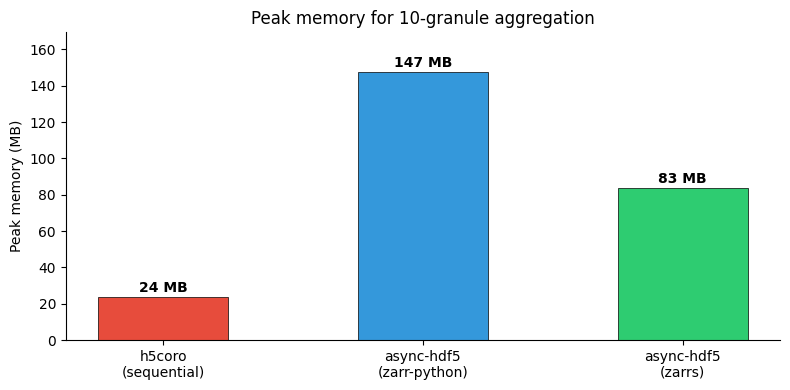

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
libraries = ["h5coro\n(sequential)", "async-hdf5\n(zarr-python)", "async-hdf5\n(zarrs)"]
peaks = [h5coro_peak, async_peak, zarrs_peak]
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.bar(
    libraries, peaks, color=colors, width=0.5, edgecolor="black", linewidth=0.5
)

for bar, peak in zip(bars, peaks):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(peaks) * 0.02,
        f"{peak:.0f} MB",
        ha="center",
        fontweight="bold",
    )

ax.set_ylabel("Peak memory (MB)")
ax.set_title(f"Peak memory: {len(urls)} granules x {len(BEAMS)} beams")
ax.set_ylim(0, max(peaks) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

## Cleanup

In [ ]:
import shutil

shutil.rmtree(tmpdir)
print("Temporary memray files cleaned up")

h5coro shows lower peak Python memory because it processes one granule
at a time, so only one set of buffers is live at any moment. The
concurrent approaches hold all in-flight data simultaneously, trading
higher peak memory for much faster wall-clock time.

zarrs-python moves decompression buffers to Rust, which memray can't
see. The flamegraphs above show where Python-side memory is allocated
in each case, which helps identify remaining optimization targets.

For magg's 300-400 granules per Lambda worker, the key question is
whether peak memory fits in the 10 GB Lambda limit
([englacial/magg#4](https://github.com/englacial/magg/issues/4)).
Bounded concurrency (e.g., `asyncio.Semaphore`) can cap the number
of in-flight granules to trade some speed for lower peak memory.